In [1]:
import itertools
import math
import random
import time
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from IPython.display import display
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)
torch.set_num_threads(min(4, max(1, torch.get_num_threads())))

# CPU is intentional here: this is a deterministic algorithmic unit test.
device = torch.device('cpu')
np.set_printoptions(precision=3, suppress=True)
print('device:', device)
print('seed:', SEED)

device: cpu
seed: 7


## 1. Configuration

In [2]:
# simulation
N = 240
L = 100
p = 40
A = D = 3

I_CONDITIONS = np.array([
    [0, 0, 0],
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1],
], dtype=np.float32)

# observation model used to generate Y
OBS_NONLINEAR_STRENGTH = 0.10
OBS_NOISE_SD = 0.03

# one-stage optimization
MAX_OUTER = 100
SHORT_RUN_OUTER = 20

LR_REP = 5e-4
LR_MILESTONES = [8, 14, 20]  # absolute; independent of MAX_OUTER
LR_GAMMA = 0.20

RECON_SIGMA = 0.20
BETA_ID = 1.00
BETA_DYN = 0.01

# unchanged v111 graph / H fit
RIDGE = 1e-3
VAL_FRAC = 0.25
LAMBDA_LAG_SCORE = 0.005
LAMBDA_INST_SCORE = 0.003

# score-directed particles
N_PARTICLES = 32
INITIAL_GRAPH_EDITS_MAX = 3
GRAPH_MOVES_PER_OUTER = 3
TAU_GRAPH = 1e-3       # fixed Gumbel perturbation scale
ETA_H = 0.65             # movement toward perturbed v111 H target
TAU_H = 1.0              # local covariance multiplier
TAU_LOGVAR = 0.025        # small fixed log-variance spread

# convergence after the final absolute LR milestone
MIN_CONVERGENCE_ITER = 24
CONVERGENCE_PATIENCE = 4
LOSS_REL_TOL = 2e-5
W_REL_TOL = 2e-4
Z_REL_TOL = 1e-5
H_REL_TOL = 2e-4

# assignment diagnostic
SINKHORN_TEMP = 0.15
SINKHORN_ITERS = 200

print({
    'N': N, 'L': L, 'p': p, 'A': A,
    'particles': N_PARTICLES,
    'tau_graph': TAU_GRAPH,
    'eta_H': ETA_H,
    'MAX_OUTER': MAX_OUTER,
    'fixed beta_id': BETA_ID,
    'fixed beta_dyn': BETA_DYN,
    'absolute LR milestones': LR_MILESTONES,
})

{'N': 240, 'L': 100, 'p': 40, 'A': 3, 'particles': 32, 'tau_graph': 0.001, 'eta_H': 0.65, 'MAX_OUTER': 100, 'fixed beta_id': 1.0, 'fixed beta_dyn': 0.01, 'absolute LR milestones': [8, 14, 20]}


## 2. Latent temporal causal simulation

In [3]:
def adj_from_edges(edges, d=A):
    G = np.zeros((d, d), dtype=np.float32)  # row parent, column child
    for parent, child in edges:
        G[parent, child] = 1.0
    return G


TRUE_LAG = adj_from_edges([(0, 1), (0, 2), (1, 2)])
TRUE_INST = adj_from_edges([(0, 1), (1, 2)])


def is_dag(G):
    G = (G > 0.5).astype(int)
    indegree = G.sum(axis=0).astype(int).tolist()
    queue = [j for j in range(G.shape[0]) if indegree[j] == 0]
    seen = 0
    while queue:
        u = queue.pop(0)
        seen += 1
        for v in range(G.shape[0]):
            if G[u, v]:
                indegree[v] -= 1
                if indegree[v] == 0:
                    queue.append(v)
    return seen == G.shape[0]


def topo_order(G):
    G = (G > 0.5).astype(int)
    indegree = G.sum(axis=0).astype(int).tolist()
    queue = [j for j in range(G.shape[0]) if indegree[j] == 0]
    order = []
    while queue:
        u = queue.pop(0)
        order.append(u)
        for v in range(G.shape[0]):
            if G[u, v]:
                indegree[v] -= 1
                if indegree[v] == 0:
                    queue.append(v)
    if len(order) != G.shape[0]:
        raise ValueError('instantaneous graph is not a DAG')
    return order


print('TRUE_LAG:')
print(TRUE_LAG.astype(int))
print('TRUE_INST:')
print(TRUE_INST.astype(int))
print('instantaneous DAG?', is_dag(TRUE_INST))
print('topological order:', [j + 1 for j in topo_order(TRUE_INST)])

TRUE_LAG:
[[0 1 1]
 [0 0 1]
 [0 0 0]]
TRUE_INST:
[[0 1 0]
 [0 0 1]
 [0 0 0]]
instantaneous DAG? True
topological order: [1, 2, 3]


In [4]:
rng_sim = np.random.default_rng(SEED)

true_self = np.array([0.55, 0.45, 0.50], dtype=np.float32)
true_bias = np.array([0.10, -0.10, 0.05], dtype=np.float32)

true_lag_coef = np.zeros((A, A), dtype=np.float32)
true_lag_coef[0, 1] = 0.80
true_lag_coef[0, 2] = -0.60
true_lag_coef[1, 2] = 0.70

true_inst_coef = np.zeros((A, A), dtype=np.float32)
true_inst_coef[0, 1] = 0.65
true_inst_coef[1, 2] = -0.55

true_noise_sd = np.array([0.20, 0.20, 0.20], dtype=np.float32)
true_int_mean = np.array([-2.0, 2.0, -1.5], dtype=np.float32)
true_int_sd = np.array([0.30, 0.30, 0.30], dtype=np.float32)


def simulate_latent_system():
    intervention_index = rng_sim.integers(0, len(I_CONDITIONS), size=N)
    I_np = I_CONDITIONS[intervention_index].astype(np.float32)

    Z = np.zeros((N, L, A), dtype=np.float32)
    Z[:, 0, :] = rng_sim.normal(0, 1, size=(N, A)).astype(np.float32)

    order = topo_order(TRUE_INST)
    for i in range(N):
        for t in range(1, L):
            z_prev = Z[i, t - 1].copy()
            z_curr = np.zeros(A, dtype=np.float32)

            for a in order:
                if I_np[i, a] > 0.5:
                    z_curr[a] = rng_sim.normal(true_int_mean[a], true_int_sd[a])
                else:
                    mu = true_bias[a] + true_self[a] * z_prev[a]
                    for k in range(A):
                        if TRUE_LAG[k, a] > 0.5:
                            mu += true_lag_coef[k, a] * np.tanh(z_prev[k])
                    for k in range(A):
                        if TRUE_INST[k, a] > 0.5:
                            mu += true_inst_coef[k, a] * np.tanh(z_curr[k])
                    z_curr[a] = rng_sim.normal(mu, true_noise_sd[a])

            Z[i, t] = z_curr

    return Z, I_np, intervention_index


Z_true_np, I_np, I_index = simulate_latent_system()
print('Z_true:', Z_true_np.shape)
print('intervention counts:',
      pd.Series(I_index).value_counts().sort_index().to_dict())

Z_true: (240, 100, 3)
intervention counts: {0: 54, 1: 56, 2: 64, 3: 66}


## 3. Mildly nonlinear high-dimensional observations

In [5]:
rng_obs = np.random.default_rng(SEED + 200)

B_linear = rng_obs.normal(size=(A, p)).astype(np.float32)
U_obs, _, Vt_obs = np.linalg.svd(B_linear, full_matrices=False)
B_linear = (2.0 * (U_obs @ Vt_obs)).astype(np.float32)

W_nonlinear = rng_obs.normal(0, 0.8, size=(A, 24)).astype(np.float32)
B_nonlinear = rng_obs.normal(
    0, 1.0 / np.sqrt(24), size=(24, p)
).astype(np.float32)

Y_np = (
    Z_true_np @ B_linear
    + OBS_NONLINEAR_STRENGTH
      * (np.tanh(Z_true_np @ W_nonlinear) @ B_nonlinear)
    + rng_obs.normal(0, OBS_NOISE_SD, size=(N, L, p)).astype(np.float32)
)

Y_mean = Y_np.reshape(-1, p).mean(axis=0, keepdims=True)
Y_std = Y_np.reshape(-1, p).std(axis=0, keepdims=True) + 1e-6
Y_np = ((Y_np - Y_mean) / Y_std).astype(np.float32)

split_rng = np.random.default_rng(SEED + 11)
indices = np.arange(N)
split_rng.shuffle(indices)
n_val = int(round(VAL_FRAC * N))
val_idx = indices[:n_val]
train_idx = indices[n_val:]

Y = torch.tensor(Y_np, dtype=torch.float32, device=device)
I_torch = torch.tensor(I_np, dtype=torch.float32, device=device)

print('Y:', Y_np.shape)
print('train/validation trajectories:', len(train_idx), len(val_idx))
print('training intervention counts:',
      pd.Series(I_index[train_idx]).value_counts().sort_index().to_dict())

Y: (240, 100, 40)
train/validation trajectories: 180 60
training intervention counts: {0: 36, 1: 42, 2: 52, 3: 50}


## 4. Observation model \((\phi,	heta)\)

In [6]:
class LinearPCAEncoder(nn.Module):
    def __init__(self, Y_train, p, d):
        super().__init__()
        pca = PCA(n_components=d, random_state=SEED)
        pca.fit(Y_train.reshape(-1, p))

        self.linear = nn.Linear(p, d)
        with torch.no_grad():
            self.linear.weight.copy_(
                torch.tensor(pca.components_, dtype=torch.float32)
            )
            self.linear.bias.copy_(
                torch.tensor(
                    -pca.mean_ @ pca.components_.T,
                    dtype=torch.float32,
                )
            )

    def forward(self, y):
        return self.linear(y)


class ResidualDecoder(nn.Module):
    def __init__(self, encoder, Y_train, d, p, hidden=32, residual_scale=0.10):
        super().__init__()
        self.base = nn.Linear(d, p)

        with torch.no_grad():
            y_flat = Y_train.reshape(-1, p)
            x_flat = encoder(
                torch.tensor(y_flat, dtype=torch.float32)
            ).cpu().numpy()
            design = np.concatenate(
                [x_flat, np.ones((len(x_flat), 1))],
                axis=1,
            )
            coefficient = np.linalg.lstsq(design, y_flat, rcond=None)[0]
            self.base.weight.copy_(
                torch.tensor(coefficient[:-1].T, dtype=torch.float32)
            )
            self.base.bias.copy_(
                torch.tensor(coefficient[-1], dtype=torch.float32)
            )

        self.residual = nn.Sequential(
            nn.Linear(d, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, p),
        )
        nn.init.zeros_(self.residual[-1].weight)
        nn.init.zeros_(self.residual[-1].bias)
        self.residual_scale = residual_scale

    def forward(self, x):
        return self.base(x) + self.residual_scale * self.residual(x)


def initialize_models():
    # Re-seeding here makes independent short/long runs start identically.
    torch.manual_seed(SEED)
    encoder = LinearPCAEncoder(Y_np[train_idx], p, D).to(device)
    decoder = ResidualDecoder(
        encoder, Y_np[train_idx], D, p
    ).to(device)

    optimizer = torch.optim.AdamW(
        list(encoder.parameters()) + list(decoder.parameters()),
        lr=LR_REP,
        weight_decay=1e-6,
    )
    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=LR_MILESTONES,
        gamma=LR_GAMMA,
    )
    return encoder, decoder, optimizer, scheduler

## 5. Coordinate map $\psi$

In [7]:
def encode_all_np(encoder):
    encoder.eval()
    with torch.no_grad():
        X = encoder(Y.reshape(-1, p)).reshape(N, L, D)
    encoder.train()
    return X.detach().cpu().numpy().astype(np.float64)


def whitening_from_training(X):
    values = X[train_idx].reshape(-1, D)
    mean = values.mean(axis=0)
    centered = values - mean
    covariance = np.cov(centered, rowvar=False) + 1e-6 * np.eye(D)
    eigenvalue, eigenvector = np.linalg.eigh(covariance)
    whitening = (
        eigenvector
        @ np.diag(1.0 / np.sqrt(eigenvalue))
        @ eigenvector.T
    )
    return mean, whitening


def mechanism_break_coordinate_update(X_white, W_previous=None):
    rows = []
    singular_values = []

    for a in range(A):
        active_train = train_idx[I_np[train_idx, a] > 0.5]
        curr = X_white[active_train, 1:, :].reshape(-1, D)
        prev = X_white[active_train, :-1, :].reshape(-1, D)

        curr = curr - curr.mean(axis=0, keepdims=True)
        prev = prev - prev.mean(axis=0, keepdims=True)
        C_a = curr.T @ prev / max(len(curr) - 1, 1)

        U, singular, _ = np.linalg.svd(C_a, full_matrices=True)
        w_a = U[:, -1]

        if W_previous is not None and np.dot(w_a, W_previous[a]) < 0:
            w_a = -w_a

        rows.append(w_a)
        singular_values.append(singular)

    W = np.stack(rows, axis=0)
    W /= np.linalg.norm(W, axis=1, keepdims=True) + 1e-12
    return W, np.stack(singular_values, axis=0)


def baseline_standardization(Z_raw):
    baseline_train = train_idx[I_np[train_idx].sum(axis=1) == 0]
    values = Z_raw[baseline_train].reshape(-1, A)
    mean = values.mean(axis=0)
    std = values.std(axis=0) + 1e-8
    return (Z_raw - mean) / std, mean, std


def transform_all(X, W_previous=None):
    x_mean, x_whitening = whitening_from_training(X)
    X_white = (X - x_mean) @ x_whitening
    W, crosscov_singular = mechanism_break_coordinate_update(
        X_white,
        W_previous=W_previous,
    )
    Z_raw = X_white @ W.T
    Z, z_mean, z_std = baseline_standardization(Z_raw)

    return {
        'X': X,
        'X_white': X_white,
        'x_mean': x_mean,
        'x_whitening': x_whitening,
        'W': W,
        'crosscov_singular': crosscov_singular,
        'Z_raw': Z_raw,
        'Z': Z,
        'z_mean': z_mean,
        'z_std': z_std,
    }

## 6. Profiled score and mechanism fit

In [8]:
def enumerate_lag_graphs(a=A):
    edges = [(i, j) for i in range(a) for j in range(a) if i != j]
    graphs = []
    for bits in itertools.product([0, 1], repeat=len(edges)):
        G = np.zeros((a, a), dtype=np.float32)
        for bit, edge in zip(bits, edges):
            G[edge] = bit
        graphs.append(G)
    return graphs


def enumerate_inst_dags(a=A):
    edges = [(i, j) for i in range(a) for j in range(a) if i != j]
    graphs = []
    for bits in itertools.product([0, 1], repeat=len(edges)):
        G = np.zeros((a, a), dtype=np.float32)
        for bit, edge in zip(bits, edges):
            G[edge] = bit
        if is_dag(G):
            graphs.append(G)
    return graphs


LAG_GRAPHS = enumerate_lag_graphs()
INST_GRAPHS = enumerate_inst_dags()
print('lag graphs:', len(LAG_GRAPHS))
print('instantaneous DAGs:', len(INST_GRAPHS))
print('global pairs:', len(LAG_GRAPHS) * len(INST_GRAPHS))

lag graphs: 64
instantaneous DAGs: 25
global pairs: 1600


In [9]:
def parent_tuple(G, child):
    return tuple(np.where(G[:, child] > 0.5)[0].tolist())


def local_design(z_prev, z_curr, lag_parents, inst_parents, child):
    columns = [
        np.ones(len(z_prev), dtype=np.float64),
        z_prev[:, child].astype(np.float64),
    ]
    columns.extend(np.tanh(z_prev[:, k]) for k in lag_parents)
    columns.extend(np.tanh(z_curr[:, k]) for k in inst_parents)
    return np.stack(columns, axis=1)


def ridge_gaussian_fit(X_design, y, ridge=RIDGE):
    gram = X_design.T @ X_design
    precision = gram + ridge * np.eye(X_design.shape[1])
    rhs = X_design.T @ y
    beta = np.linalg.solve(precision, rhs)
    residual = y - X_design @ beta
    variance = float(np.clip(
        np.mean(residual ** 2),
        0.05 ** 2,
        2.0 ** 2,
    ))
    covariance = variance * np.linalg.inv(precision)
    return beta, variance, covariance


def graph_distance(G_lag, G_inst):
    d_lag = int(np.abs(G_lag - TRUE_LAG).sum())
    d_inst = int(np.abs(G_inst - TRUE_INST).sum())
    return d_lag + d_inst, d_lag, d_inst


def fit_local_score_cache(Z):
    z_prev_train = Z[train_idx, :-1].reshape(-1, A)
    z_curr_train = Z[train_idx, 1:].reshape(-1, A)
    intervention_train = np.repeat(I_np[train_idx], L - 1, axis=0)

    z_prev_val = Z[val_idx, :-1].reshape(-1, A)
    z_curr_val = Z[val_idx, 1:].reshape(-1, A)
    intervention_val = np.repeat(I_np[val_idx], L - 1, axis=0)

    cache = {}
    for child in range(A):
        other = [k for k in range(A) if k != child]

        for lag_bits in itertools.product([0, 1], repeat=len(other)):
            lag_parents = tuple(k for k, bit in zip(other, lag_bits) if bit)

            for inst_bits in itertools.product([0, 1], repeat=len(other)):
                inst_parents = tuple(k for k, bit in zip(other, inst_bits) if bit)

                obs_train = intervention_train[:, child] < 0.5
                X_train = local_design(
                    z_prev_train[obs_train],
                    z_curr_train[obs_train],
                    lag_parents,
                    inst_parents,
                    child,
                )
                y_train = z_curr_train[obs_train, child]
                beta, obs_var, beta_cov = ridge_gaussian_fit(X_train, y_train)

                int_train = ~obs_train
                y_int = z_curr_train[int_train, child]
                int_mean = float(y_int.mean())
                int_var = float(np.clip(
                    np.mean((y_int - int_mean) ** 2),
                    0.05 ** 2,
                    2.0 ** 2,
                ))

                obs_val = intervention_val[:, child] < 0.5
                X_val = local_design(
                    z_prev_val[obs_val],
                    z_curr_val[obs_val],
                    lag_parents,
                    inst_parents,
                    child,
                )
                y_val = z_curr_val[obs_val, child]
                pred = X_val @ beta
                ll_obs = -0.5 * (
                    np.log(2 * np.pi * obs_var)
                    + (y_val - pred) ** 2 / obs_var
                )

                int_val = ~obs_val
                y_val_int = z_curr_val[int_val, child]
                ll_int = -0.5 * (
                    np.log(2 * np.pi * int_var)
                    + (y_val_int - int_mean) ** 2 / int_var
                )

                total_ll = float(ll_obs.sum() + ll_int.sum())
                total_n = len(ll_obs) + len(ll_int)

                cache[(child, lag_parents, inst_parents)] = {
                    'avg_ll': total_ll / max(total_n, 1),
                    'beta': beta,
                    'beta_cov': beta_cov,
                    'obs_var': obs_var,
                    'int_mean': int_mean,
                    'int_var': int_var,
                    'n_int': max(int(y_int.size), 1),
                    'lag_parents': lag_parents,
                    'inst_parents': inst_parents,
                }

    return cache


# Enumerated graph pairs are used only as a finite state space for score lookup.
GRAPH_PAIRS = []
PAIR_LOOKUP = {}
for lag_index, G_lag in enumerate(LAG_GRAPHS):
    for inst_index, G_inst in enumerate(INST_GRAPHS):
        pair_index = len(GRAPH_PAIRS)
        GRAPH_PAIRS.append((G_lag.copy(), G_inst.copy()))
        PAIR_LOOKUP[(G_lag.astype(np.int8).tobytes(),
                     G_inst.astype(np.int8).tobytes())] = pair_index


def score_graph_pairs(cache):
    scores = np.empty(len(GRAPH_PAIRS), dtype=np.float64)
    avg_lls = np.empty_like(scores)
    penalties = np.empty_like(scores)

    for pair_index, (G_lag, G_inst) in enumerate(GRAPH_PAIRS):
        local_ll = []
        for child in range(A):
            fit = cache[
                child,
                parent_tuple(G_lag, child),
                parent_tuple(G_inst, child),
            ]
            local_ll.append(fit['avg_ll'])

        avg_ll = float(np.mean(local_ll))
        penalty = (
            LAMBDA_LAG_SCORE * float(G_lag.sum())
            + LAMBDA_INST_SCORE * float(G_inst.sum())
        )
        scores[pair_index] = avg_ll - penalty
        avg_lls[pair_index] = avg_ll
        penalties[pair_index] = penalty

    return scores, avg_lls, penalties


def v111_best_graph(scores):
    pair_index = int(np.argmax(scores))
    G_lag, G_inst = GRAPH_PAIRS[pair_index]
    d_total, d_lag, d_inst = graph_distance(G_lag, G_inst)
    return {
        'pair_index': pair_index,
        'score': float(scores[pair_index]),
        'G_lag': G_lag.copy(),
        'G_inst': G_inst.copy(),
        'd_total': d_total,
        'd_lag': d_lag,
        'd_inst': d_inst,
    }


def H_fit_for_pair(cache, pair_index):
    G_lag, G_inst = GRAPH_PAIRS[pair_index]
    return [
        cache[
            child,
            parent_tuple(G_lag, child),
            parent_tuple(G_inst, child),
        ].copy()
        for child in range(A)
    ]


# Valid local graph neighborhoods: lag add/delete; instantaneous add/delete/reverse.
def graph_pair_index(G_lag, G_inst):
    return PAIR_LOOKUP[(G_lag.astype(np.int8).tobytes(),
                        G_inst.astype(np.int8).tobytes())]


def make_graph_neighbors(pair_index):
    G_lag, G_inst = GRAPH_PAIRS[pair_index]
    neighbors = {pair_index}

    for parent in range(A):
        for child in range(A):
            if parent == child:
                continue

            lag_new = G_lag.copy()
            lag_new[parent, child] = 1.0 - lag_new[parent, child]
            neighbors.add(graph_pair_index(lag_new, G_inst))

            inst_new = G_inst.copy()
            inst_new[parent, child] = 1.0 - inst_new[parent, child]
            if is_dag(inst_new):
                neighbors.add(graph_pair_index(G_lag, inst_new))

            if G_inst[parent, child] > 0.5:
                inst_reverse = G_inst.copy()
                inst_reverse[parent, child] = 0.0
                inst_reverse[child, parent] = 1.0
                if is_dag(inst_reverse):
                    neighbors.add(graph_pair_index(G_lag, inst_reverse))

    return np.array(sorted(neighbors), dtype=int)


GRAPH_NEIGHBORS = [make_graph_neighbors(j) for j in range(len(GRAPH_PAIRS))]
print('graph pairs:', len(GRAPH_PAIRS))
print('mean local neighborhood size:', np.mean([len(x) for x in GRAPH_NEIGHBORS]))

graph pairs: 1600
mean local neighborhood size: 12.52


## 7. Fixed perturbations and direct particle movement

In [10]:
CANONICAL_BETA_DIM = 2 + 2 * A


def canonical_active_indices(child, lag_parents, inst_parents):
    indices = [0, 1]
    indices.extend(2 + parent for parent in lag_parents)
    indices.extend(2 + A + parent for parent in inst_parents)
    return np.asarray(indices, dtype=int)


def fit_to_canonical(fit, child):
    beta_full = np.zeros(CANONICAL_BETA_DIM, dtype=np.float64)
    active = canonical_active_indices(
        child,
        fit['lag_parents'],
        fit['inst_parents'],
    )
    beta_full[active] = fit['beta']
    return beta_full, active


def initialize_fixed_particle_noise():
    rng = np.random.default_rng(SEED + 700)
    uniform = np.clip(
        rng.uniform(size=(N_PARTICLES, len(GRAPH_PAIRS))),
        1e-12,
        1 - 1e-12,
    )
    graph_gumbel = -np.log(-np.log(uniform))

    return {
        'graph_gumbel': graph_gumbel,
        'beta_normal': rng.normal(
            size=(N_PARTICLES, A, CANONICAL_BETA_DIM)
        ),
        'obs_logvar_normal': rng.normal(size=(N_PARTICLES, A)),
        'int_mean_normal': rng.normal(size=(N_PARTICLES, A)),
        'int_logvar_normal': rng.normal(size=(N_PARTICLES, A)),
        'initial_edit_uniform': rng.uniform(
            size=(N_PARTICLES, INITIAL_GRAPH_EDITS_MAX, 2)
        ),
    }


def perturbed_H_target(fit, child, particle_index, fixed_noise):
    beta_full, active = fit_to_canonical(fit, child)
    covariance = fit['beta_cov']
    cholesky = np.linalg.cholesky(
        covariance + 1e-12 * np.eye(covariance.shape[0])
    )
    epsilon = fixed_noise['beta_normal'][particle_index, child, active]
    beta_full[active] += np.sqrt(TAU_H) * (cholesky @ epsilon)

    obs_var = fit['obs_var'] * np.exp(
        TAU_LOGVAR * fixed_noise['obs_logvar_normal'][particle_index, child]
    )
    int_mean = fit['int_mean'] + np.sqrt(
        TAU_H * fit['int_var'] / fit['n_int']
    ) * fixed_noise['int_mean_normal'][particle_index, child]
    int_var = fit['int_var'] * np.exp(
        TAU_LOGVAR * fixed_noise['int_logvar_normal'][particle_index, child]
    )

    return {
        'beta_full': beta_full,
        'obs_var': float(np.clip(obs_var, 0.05 ** 2, 2.0 ** 2)),
        'int_mean': float(int_mean),
        'int_var': float(np.clip(int_var, 0.05 ** 2, 2.0 ** 2)),
    }


def blend_H(old_H, target_H, eta=ETA_H):
    if old_H is None:
        return deepcopy(target_H)
    return {
        'beta_full': (1 - eta) * old_H['beta_full'] + eta * target_H['beta_full'],
        'obs_var': float(np.exp(
            (1 - eta) * np.log(old_H['obs_var'])
            + eta * np.log(target_H['obs_var'])
        )),
        'int_mean': float(
            (1 - eta) * old_H['int_mean'] + eta * target_H['int_mean']
        ),
        'int_var': float(np.exp(
            (1 - eta) * np.log(old_H['int_var'])
            + eta * np.log(target_H['int_var'])
        )),
    }


def perturb_initial_graphs(center_pair_index, fixed_noise):
    pair_indices = []
    for particle_index in range(N_PARTICLES):
        current = center_pair_index
        for step in range(INITIAL_GRAPH_EDITS_MAX):
            u_use, u_neighbor = fixed_noise['initial_edit_uniform'][
                particle_index, step
            ]
            if u_use > 0.70:
                continue
            candidates = GRAPH_NEIGHBORS[current]
            nonself = candidates[candidates != current]
            if len(nonself) == 0:
                continue
            chosen = min(int(u_neighbor * len(nonself)), len(nonself) - 1)
            current = int(nonself[chosen])
        pair_indices.append(current)
    return np.asarray(pair_indices, dtype=int)


def initialize_particles(cache, scores, fixed_noise):
    center = int(np.argmax(scores))
    pair_indices = perturb_initial_graphs(center, fixed_noise)
    H_particles = []

    for particle_index, pair_index in enumerate(pair_indices):
        fits = H_fit_for_pair(cache, int(pair_index))
        H_particles.append([
            perturbed_H_target(
                fits[child], child, particle_index, fixed_noise
            )
            for child in range(A)
        ])

    return pair_indices, H_particles


def move_graph_particles(pair_indices, scores, fixed_noise):
    new_indices = pair_indices.copy()
    perturbed_scores = (
        scores[None, :]
        + TAU_GRAPH * fixed_noise['graph_gumbel']
    )

    for particle_index in range(N_PARTICLES):
        current = int(new_indices[particle_index])
        for _ in range(GRAPH_MOVES_PER_OUTER):
            neighbors = GRAPH_NEIGHBORS[current]
            values = perturbed_scores[particle_index, neighbors]
            proposed = int(neighbors[int(np.argmax(values))])
            if proposed == current:
                break
            current = proposed
        new_indices[particle_index] = current

    changed_fraction = float(np.mean(new_indices != pair_indices))
    return new_indices, changed_fraction


def update_H_particles(
    old_particles,
    pair_indices,
    cache,
    fixed_noise,
):
    new_particles = []
    squared_change = 0.0
    squared_old = 0.0

    for particle_index, pair_index in enumerate(pair_indices):
        fits = H_fit_for_pair(cache, int(pair_index))
        particle_H = []
        for child in range(A):
            target = perturbed_H_target(
                fits[child], child, particle_index, fixed_noise
            )
            old_H = None if old_particles is None else old_particles[particle_index][child]
            new_H = blend_H(old_H, target)
            particle_H.append(new_H)

            if old_H is not None:
                old_vector = np.concatenate([
                    old_H['beta_full'],
                    [np.log(old_H['obs_var']), old_H['int_mean'],
                     np.log(old_H['int_var'])],
                ])
                new_vector = np.concatenate([
                    new_H['beta_full'],
                    [np.log(new_H['obs_var']), new_H['int_mean'],
                     np.log(new_H['int_var'])],
                ])
                squared_change += float(np.sum((new_vector - old_vector) ** 2))
                squared_old += float(np.sum(old_vector ** 2))
        new_particles.append(particle_H)

    relative_change = (
        np.sqrt(squared_change) / (np.sqrt(squared_old) + 1e-12)
        if old_particles is not None else np.inf
    )
    return new_particles, float(relative_change)


def particle_graph_summary(pair_indices):
    rows = []
    for particle_index, pair_index in enumerate(pair_indices):
        G_lag, G_inst = GRAPH_PAIRS[int(pair_index)]
        d_total, d_lag, d_inst = graph_distance(G_lag, G_inst)
        rows.append({
            'particle': particle_index,
            'pair_index': int(pair_index),
            'd_total': d_total,
            'd_lag': d_lag,
            'd_inst': d_inst,
        })
    return pd.DataFrame(rows)


def edge_inclusion_probabilities(pair_indices):
    lag = np.mean(
        [GRAPH_PAIRS[int(j)][0] for j in pair_indices], axis=0
    )
    inst = np.mean(
        [GRAPH_PAIRS[int(j)][1] for j in pair_indices], axis=0
    )
    return lag, inst

## 8. Differentiable representation losses with fixed particles

In [11]:
def torch_coordinate_transform(x, coordinate_state):
    x_mean = torch.tensor(
        coordinate_state['x_mean'], dtype=x.dtype, device=x.device
    )
    x_whitening = torch.tensor(
        coordinate_state['x_whitening'], dtype=x.dtype, device=x.device
    )
    W_transpose = torch.tensor(
        coordinate_state['W'].T, dtype=x.dtype, device=x.device
    )
    z_mean = torch.tensor(
        coordinate_state['z_mean'], dtype=x.dtype, device=x.device
    )
    z_std = torch.tensor(
        coordinate_state['z_std'], dtype=x.dtype, device=x.device
    )

    x_white = (x - x_mean) @ x_whitening
    z_raw = x_white @ W_transpose
    z = (z_raw - z_mean) / z_std
    return z, x_white


def crosscov_ratio_loss(x_white, intervention_batch, W_np):
    W = torch.tensor(W_np, dtype=x_white.dtype, device=x_white.device)
    losses = []

    for a in range(A):
        active = intervention_batch[:, a] > 0.5
        inactive = ~active

        def crosscov(mask):
            curr = x_white[mask, 1:].reshape(-1, D)
            prev = x_white[mask, :-1].reshape(-1, D)
            curr = curr - curr.mean(dim=0, keepdim=True)
            prev = prev - prev.mean(dim=0, keepdim=True)
            return curr.T @ prev / max(curr.shape[0] - 1, 1)

        C_int = crosscov(active)
        C_obs = crosscov(inactive)
        numerator = torch.sum((W[a] @ C_int) ** 2)
        denominator = torch.sum((W[a] @ C_obs) ** 2)
        losses.append(numerator / (denominator + 1e-6))

    return torch.stack(losses).mean()


def particle_dynamics_nll(z, intervention_batch, pair_indices, H_particles):
    G_lag = torch.tensor(
        np.stack([GRAPH_PAIRS[int(j)][0] for j in pair_indices]),
        dtype=z.dtype,
        device=z.device,
    )
    G_inst = torch.tensor(
        np.stack([GRAPH_PAIRS[int(j)][1] for j in pair_indices]),
        dtype=z.dtype,
        device=z.device,
    )
    beta = torch.tensor(
        np.asarray([
            [H_particles[m][a]['beta_full'] for a in range(A)]
            for m in range(len(pair_indices))
        ]),
        dtype=z.dtype,
        device=z.device,
    )
    obs_var = torch.tensor(
        np.asarray([
            [H_particles[m][a]['obs_var'] for a in range(A)]
            for m in range(len(pair_indices))
        ]),
        dtype=z.dtype,
        device=z.device,
    )
    int_mean = torch.tensor(
        np.asarray([
            [H_particles[m][a]['int_mean'] for a in range(A)]
            for m in range(len(pair_indices))
        ]),
        dtype=z.dtype,
        device=z.device,
    )
    int_var = torch.tensor(
        np.asarray([
            [H_particles[m][a]['int_var'] for a in range(A)]
            for m in range(len(pair_indices))
        ]),
        dtype=z.dtype,
        device=z.device,
    )

    z_prev = z[:, :-1]
    z_curr = z[:, 1:]
    child_losses = []

    for child in range(A):
        prediction = (
            beta[:, child, 0, None, None]
            + beta[:, child, 1, None, None]
              * z_prev[None, :, :, child]
        )

        for parent in range(A):
            lag_coefficient = (
                beta[:, child, 2 + parent]
                * G_lag[:, parent, child]
            )[:, None, None]
            inst_coefficient = (
                beta[:, child, 2 + A + parent]
                * G_inst[:, parent, child]
            )[:, None, None]
            prediction = (
                prediction
                + lag_coefficient * torch.tanh(
                    z_prev[None, :, :, parent]
                )
                + inst_coefficient * torch.tanh(
                    z_curr[None, :, :, parent]
                )
            )

        target = z_curr[None, :, :, child]
        intervened = (
            intervention_batch[:, child][None, :, None] > 0.5
        )
        obs_nll = 0.5 * (
            torch.log(2 * math.pi * obs_var[:, child, None, None])
            + (target - prediction) ** 2
              / obs_var[:, child, None, None]
        )
        int_nll = 0.5 * (
            torch.log(2 * math.pi * int_var[:, child, None, None])
            + (target - int_mean[:, child, None, None]) ** 2
              / int_var[:, child, None, None]
        )
        child_losses.append(
            torch.where(intervened, int_nll, obs_nll).mean()
        )

    return torch.stack(child_losses).mean()


## 9. One-stage deterministic particle block-coordinate training

In [12]:
def dense_affine_r2(X, split=val_idx):
    x = X[split].reshape(-1, D)
    y = Z_true_np[split].reshape(-1, A)
    design = np.concatenate([x, np.ones((len(x), 1))], axis=1)
    beta = np.linalg.lstsq(design, y, rcond=None)[0]
    prediction = design @ beta
    return float(r2_score(y, prediction, multioutput='variance_weighted'))


def coordinate_affine_r2(Z, split=val_idx):
    values = []
    for a in range(A):
        x = Z[split, :, a].reshape(-1)
        y = Z_true_np[split, :, a].reshape(-1)
        design = np.stack([x, np.ones_like(x)], axis=1)
        beta = np.linalg.lstsq(design, y, rcond=None)[0]
        values.append(r2_score(y, design @ beta))
    return np.asarray(values)


def particle_prediction_diagnostics(Z, pair_indices, H_particles, split=val_idx):
    z_prev = Z[split, :-1].reshape(-1, A)
    z_curr = Z[split, 1:].reshape(-1, A)
    interventions = np.repeat(I_np[split], L - 1, axis=0)

    G_lag = np.stack([GRAPH_PAIRS[int(j)][0] for j in pair_indices])
    G_inst = np.stack([GRAPH_PAIRS[int(j)][1] for j in pair_indices])
    beta = np.asarray([
        [H_particles[m][a]['beta_full'] for a in range(A)]
        for m in range(len(pair_indices))
    ])

    rows = []
    predictions_by_child = []
    targets_by_child = []

    for child in range(A):
        observed = interventions[:, child] < 0.5
        target = z_curr[observed, child]
        particle_predictions = (
            beta[:, child, 0, None]
            + beta[:, child, 1, None]
              * z_prev[None, observed, child]
        )

        for parent in range(A):
            particle_predictions = (
                particle_predictions
                + (beta[:, child, 2 + parent]
                   * G_lag[:, parent, child])[:, None]
                  * np.tanh(z_prev[None, observed, parent])
                + (beta[:, child, 2 + A + parent]
                   * G_inst[:, parent, child])[:, None]
                  * np.tanh(z_curr[None, observed, parent])
            )

        ensemble_mean = particle_predictions.mean(axis=0)
        residual = particle_predictions - target[None, :]
        denominator = np.sum((target - target.mean()) ** 2)
        particle_r2 = 1.0 - np.sum(residual ** 2, axis=1) / denominator

        rows.append({
            'child': child + 1,
            'ensemble validation R2': float(r2_score(target, ensemble_mean)),
            'mean particle validation R2': float(particle_r2.mean()),
            'minimum particle validation R2': float(particle_r2.min()),
            'prediction spread SD': float(np.mean(np.std(
                particle_predictions, axis=0
            ))),
        })
        predictions_by_child.append(particle_predictions)
        targets_by_child.append(target)

    return pd.DataFrame(rows), predictions_by_child, targets_by_child


def run_training(max_outer, early_stopping=True, verbose=False):
    encoder, decoder, optimizer, scheduler = initialize_models()
    fixed_noise = initialize_fixed_particle_noise()

    X_current = encode_all_np(encoder)
    coordinate_state = transform_all(X_current, W_previous=None)
    cache = fit_local_score_cache(coordinate_state['Z'])
    scores, _, _ = score_graph_pairs(cache)
    v111_best = v111_best_graph(scores)
    pair_indices, H_particles = initialize_particles(cache, scores, fixed_noise)

    trace_rows = []
    previous_objective = None
    stable_count = 0
    converged = False
    start_time = time.time()

    for outer in range(1, max_outer + 1):
        # Block 1: update phi and theta with the fixed particle cloud.
        optimizer.zero_grad()

        y_train = Y[train_idx]
        x_flat = encoder(y_train.reshape(-1, p))
        x_train = x_flat.reshape(len(train_idx), L, D)
        y_reconstructed = decoder(x_flat).reshape(len(train_idx), L, p)

        loss_rec = 0.5 * (((y_reconstructed - y_train) / RECON_SIGMA) ** 2).mean()
        z_train, x_white_train = torch_coordinate_transform(x_train, coordinate_state)
        loss_id = crosscov_ratio_loss(
            x_white_train,
            I_torch[train_idx],
            coordinate_state['W'],
        )
        loss_dyn = particle_dynamics_nll(
            z_train,
            I_torch[train_idx],
            pair_indices,
            H_particles,
        )

        loss = loss_rec + BETA_ID * loss_id + BETA_DYN * loss_dyn
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(encoder.parameters()) + list(decoder.parameters()),
            10.0,
        )
        optimizer.step()
        scheduler.step()

        # Block 2: unchanged coordinate-identification update.
        X_new = encode_all_np(encoder)
        coordinate_state_new = transform_all(
            X_new,
            W_previous=coordinate_state['W'],
        )

        # Block 3: direct graph-particle movement under perturbed v111 scores.
        cache_new = fit_local_score_cache(coordinate_state_new['Z'])
        scores_new, _, _ = score_graph_pairs(cache_new)
        v111_best_new = v111_best_graph(scores_new)
        pair_indices_new, graph_changed_fraction = move_graph_particles(
            pair_indices,
            scores_new,
            fixed_noise,
        )

        # Block 4: direct H-particle movement toward perturbed v111 fits.
        H_particles_new, H_relative_change = update_H_particles(
            H_particles,
            pair_indices_new,
            cache_new,
            fixed_noise,
        )

        objective = float(loss.detach().cpu())
        loss_relative_change = (
            np.nan if previous_objective is None else
            abs(objective - previous_objective) / (abs(previous_objective) + 1e-12)
        )
        W_relative_change = float(
            np.linalg.norm(coordinate_state_new['W'] - coordinate_state['W'])
            / (np.linalg.norm(coordinate_state['W']) + 1e-12)
        )
        Z_relative_change = float(
            np.linalg.norm(coordinate_state_new['Z'] - coordinate_state['Z'])
            / (np.linalg.norm(coordinate_state['Z']) + 1e-12)
        )

        coordinate_r2 = coordinate_affine_r2(coordinate_state_new['Z'])
        graph_summary = particle_graph_summary(pair_indices_new)
        H_table, _, _ = particle_prediction_diagnostics(
            coordinate_state_new['Z'],
            pair_indices_new,
            H_particles_new,
        )

        true_pair = (
            np.array_equal(GRAPH_PAIRS[int(v111_best_new['pair_index'])][0], TRUE_LAG)
            and np.array_equal(GRAPH_PAIRS[int(v111_best_new['pair_index'])][1], TRUE_INST)
        )
        particle_true_fraction = float(np.mean(
            (graph_summary['d_lag'] == 0) & (graph_summary['d_inst'] == 0)
        ))

        trace_rows.append({
            'outer': outer,
            'objective': objective,
            'rec': float(loss_rec.detach().cpu()),
            'id': float(loss_id.detach().cpu()),
            'dyn': float(loss_dyn.detach().cpu()),
            'lr': float(optimizer.param_groups[0]['lr']),
            'loss_rel_change': loss_relative_change,
            'W_rel_change': W_relative_change,
            'Z_rel_change': Z_relative_change,
            'H_rel_change': H_relative_change,
            'particle_graph_changed_fraction': graph_changed_fraction,
            'dense_affine_r2_X': dense_affine_r2(X_new),
            'z1_affine_r2': float(coordinate_r2[0]),
            'z2_affine_r2': float(coordinate_r2[1]),
            'z3_affine_r2': float(coordinate_r2[2]),
            'H1_r2': float(H_table.loc[0, 'ensemble validation R2']),
            'H2_r2': float(H_table.loc[1, 'ensemble validation R2']),
            'H3_r2': float(H_table.loc[2, 'ensemble validation R2']),
            'v111_d_lag': v111_best_new['d_lag'],
            'v111_d_inst': v111_best_new['d_inst'],
            'v111_score': v111_best_new['score'],
            'v111_is_true': true_pair,
            'particle_true_fraction': particle_true_fraction,
            'particle_mean_d_lag': float(graph_summary['d_lag'].mean()),
            'particle_mean_d_inst': float(graph_summary['d_inst'].mean()),
            'particle_unique_graphs': int(graph_summary['pair_index'].nunique()),
            'W_condition': float(np.linalg.cond(coordinate_state_new['W'])),
        })

        convergence_condition = (
            outer >= MIN_CONVERGENCE_ITER
            and not np.isnan(loss_relative_change)
            and loss_relative_change < LOSS_REL_TOL
            and W_relative_change < W_REL_TOL
            and Z_relative_change < Z_REL_TOL
            and H_relative_change < H_REL_TOL
            and graph_changed_fraction == 0.0
        )
        stable_count = stable_count + 1 if convergence_condition else 0

        coordinate_state = coordinate_state_new
        cache = cache_new
        scores = scores_new
        v111_best = v111_best_new
        pair_indices = pair_indices_new
        H_particles = H_particles_new
        previous_objective = objective

        if verbose and (
            outer == 1 or outer % 10 == 0
            or stable_count == CONVERGENCE_PATIENCE
        ):
            print(
                f"outer={outer:03d} obj={objective:.5f} "
                f"d_v111=({v111_best['d_lag']},{v111_best['d_inst']}) "
                f"true_frac={particle_true_fraction:.2f} "
                f"mean_d=({graph_summary['d_lag'].mean():.2f},"
                f"{graph_summary['d_inst'].mean():.2f}) "
                f"unique={graph_summary['pair_index'].nunique()} "
                f"coordR2={np.round(coordinate_r2, 4)}"
            )

        if early_stopping and stable_count >= CONVERGENCE_PATIENCE:
            converged = True
            break

    return {
        'encoder': encoder,
        'decoder': decoder,
        'coordinate_state': coordinate_state,
        'cache': cache,
        'scores': scores,
        'v111_best': v111_best,
        'pair_indices': pair_indices,
        'H_particles': H_particles,
        'fixed_noise': fixed_noise,
        'trace': pd.DataFrame(trace_rows),
        'converged': converged,
        'stop_iteration': len(trace_rows),
        'seconds': time.time() - start_time,
    }

## 10. Required iteration-count invariance test

In [13]:
short_result = run_training(
    max_outer=SHORT_RUN_OUTER,
    early_stopping=False,
    verbose=False,
)

long_result = run_training(
    max_outer=MAX_OUTER,
    early_stopping=True,
    verbose=True,
)

prefix_columns = [
    'objective', 'rec', 'id', 'dyn', 'lr',
    'loss_rel_change', 'W_rel_change', 'Z_rel_change', 'H_rel_change',
    'particle_graph_changed_fraction',
    'dense_affine_r2_X',
    'z1_affine_r2', 'z2_affine_r2', 'z3_affine_r2',
    'H1_r2', 'H2_r2', 'H3_r2',
    'v111_d_lag', 'v111_d_inst', 'v111_score',
    'particle_true_fraction', 'particle_mean_d_lag',
    'particle_mean_d_inst', 'particle_unique_graphs', 'W_condition',
]

short_prefix = short_result['trace'][prefix_columns].to_numpy()
long_prefix = long_result['trace'].iloc[:SHORT_RUN_OUTER][prefix_columns].to_numpy()
prefix_max_abs_difference = float(np.nanmax(np.abs(short_prefix - long_prefix)))
prefix_equal = bool(np.allclose(
    short_prefix,
    long_prefix,
    rtol=0.0,
    atol=1e-12,
    equal_nan=True,
))

invariance_table = pd.DataFrame({
    'check': [
        '20-run equals first 20 iterations of long run',
        'maximum absolute prefix difference',
        'long run convergence flag',
        'long run stopping iteration',
    ],
    'value': [
        prefix_equal,
        prefix_max_abs_difference,
        long_result['converged'],
        long_result['stop_iteration'],
    ],
})
display(invariance_table)
assert prefix_equal, 'Iteration-count invariance failed.'
print(
    f"short seconds={short_result['seconds']:.1f}; "
    f"long seconds={long_result['seconds']:.1f}"
)

outer=001 obj=0.09601 d_v111=(0,0) true_frac=0.69 mean_d=(0.12,0.19) unique=3 coordR2=[0.999 1.    0.998]
outer=010 obj=0.09564 d_v111=(0,0) true_frac=0.69 mean_d=(0.09,0.22) unique=3 coordR2=[0.999 1.    0.998]
outer=020 obj=0.09557 d_v111=(0,0) true_frac=0.69 mean_d=(0.09,0.22) unique=3 coordR2=[0.999 1.    0.998]
outer=027 obj=0.09557 d_v111=(0,0) true_frac=0.69 mean_d=(0.09,0.22) unique=3 coordR2=[0.999 1.    0.998]


,check,value
0,20-run equals first 20 iterations of long run,True
1,maximum absolute prefix difference,0.0
2,long run convergence flag,True
3,long run stopping iteration,27


short seconds=3.0; long seconds=4.1


## 11. Training, particle movement, and convergence traces

,outer,objective,rec,id,dyn,lr,loss_rel_change,W_rel_change,Z_rel_change,H_rel_change,...,H3_r2,v111_d_lag,v111_d_inst,v111_score,v111_is_true,particle_true_fraction,particle_mean_d_lag,particle_mean_d_inst,particle_unique_graphs,W_condition
17,18,0.095574,0.082410,0.003415,0.974890,0.000020,0.000016,0.000049,0.000002,0.000001,...,0.830850,0,0,-0.987485,True,0.6875,0.09375,0.21875,3,5.220468
18,19,0.095573,0.082409,0.003415,0.974889,0.000020,0.000015,0.000051,0.000002,0.000001,...,0.830850,0,0,-0.987485,True,0.6875,0.09375,0.21875,3,5.220473
19,20,0.095571,0.082407,0.003415,0.974888,0.000004,0.000015,0.000052,0.000002,0.000001,...,0.830850,0,0,-0.987484,True,0.6875,0.09375,0.21875,3,5.220479
20,21,0.095570,0.082406,0.003415,0.974887,0.000004,0.000014,0.000011,0.000000,0.000001,...,0.830850,0,0,-0.987484,True,0.6875,0.09375,0.21875,3,5.220480
21,22,0.095569,0.082406,0.003415,0.974887,0.000004,0.000003,0.000011,0.000000,0.000000,...,0.830851,0,0,-0.987484,True,0.6875,0.09375,0.21875,3,5.220481
22,23,0.095569,0.082405,0.003415,0.974887,0.000004,0.000003,0.000011,0.000000,0.000000,...,0.830851,0,0,-0.987484,True,0.6875,0.09375,0.21875,3,5.220482
23,24,0.095569,0.082405,0.003415,0.974887,0.000004,0.000003,0.000011,0.000000,0.000000,...,0.830851,0,0,-0.987483,True,0.6875,0.09375,0.21875,3,5.220484
24,25,0.095569,0.082405,0.003415,0.974887,0.000004,0.000002,0.000011,0.000000,0.000000,...,0.830851,0,0,-0.987483,True,0.6875,0.09375,0.21875,3,5.220484
25,26,0.095568,0.082405,0.003415,0.974887,0.000004,0.000002,0.000011,0.000000,0.000000,...,0.830851,0,0,-0.987483,True,0.6875,0.09375,0.21875,3,5.220485
26,27,0.095568,0.082404,0.003415,0.974887,0.000004,0.000002,0.000011,0.000000,0.000000,...,0.830851,0,0,-0.987483,True,0.6875,0.09375,0.21875,3,5.220486


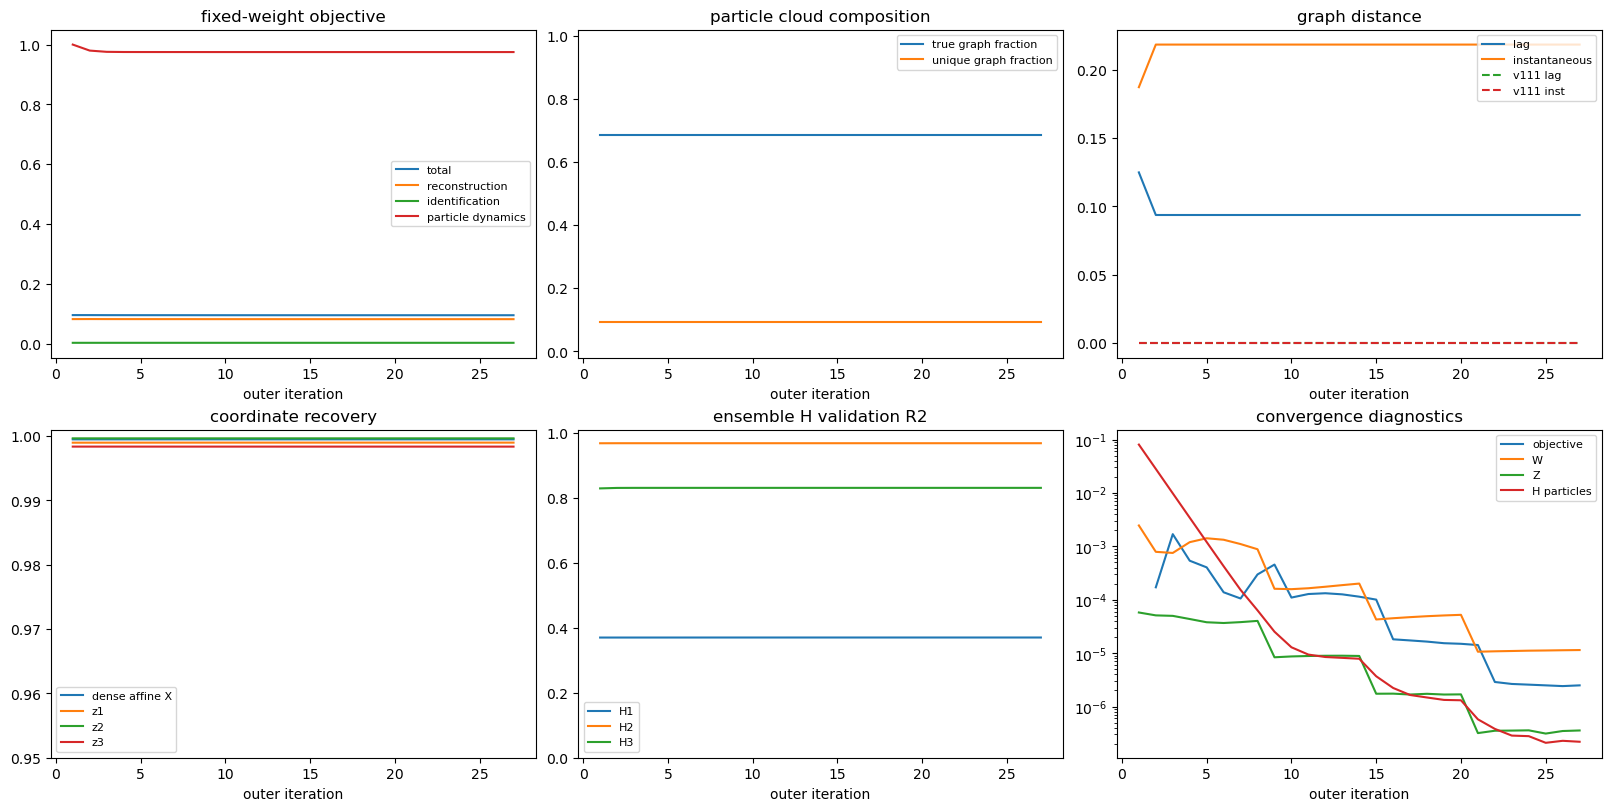

In [14]:
trace_df = long_result['trace']
display(trace_df.tail(10).round(6))

fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)

axes[0, 0].plot(trace_df['outer'], trace_df['objective'], label='total')
axes[0, 0].plot(trace_df['outer'], trace_df['rec'], label='reconstruction')
axes[0, 0].plot(trace_df['outer'], trace_df['id'], label='identification')
axes[0, 0].plot(trace_df['outer'], trace_df['dyn'], label='particle dynamics')
axes[0, 0].set_title('fixed-weight objective')
axes[0, 0].set_xlabel('outer iteration')
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(trace_df['outer'], trace_df['particle_true_fraction'], label='true graph fraction')
axes[0, 1].plot(trace_df['outer'], trace_df['particle_unique_graphs'] / N_PARTICLES,
                label='unique graph fraction')
axes[0, 1].set_ylim(-0.02, 1.02)
axes[0, 1].set_title('particle cloud composition')
axes[0, 1].set_xlabel('outer iteration')
axes[0, 1].legend(fontsize=8)

axes[0, 2].plot(trace_df['outer'], trace_df['particle_mean_d_lag'], label='lag')
axes[0, 2].plot(trace_df['outer'], trace_df['particle_mean_d_inst'], label='instantaneous')
axes[0, 2].plot(trace_df['outer'], trace_df['v111_d_lag'], '--', label='v111 lag')
axes[0, 2].plot(trace_df['outer'], trace_df['v111_d_inst'], '--', label='v111 inst')
axes[0, 2].set_title('graph distance')
axes[0, 2].set_xlabel('outer iteration')
axes[0, 2].legend(fontsize=8)

axes[1, 0].plot(trace_df['outer'], trace_df['dense_affine_r2_X'], label='dense affine X')
for a in range(A):
    axes[1, 0].plot(trace_df['outer'], trace_df[f'z{a + 1}_affine_r2'], label=f'z{a + 1}')
axes[1, 0].set_ylim(0.95, 1.001)
axes[1, 0].set_title('coordinate recovery')
axes[1, 0].set_xlabel('outer iteration')
axes[1, 0].legend(fontsize=8)

for a in range(A):
    axes[1, 1].plot(trace_df['outer'], trace_df[f'H{a + 1}_r2'], label=f'H{a + 1}')
axes[1, 1].set_ylim(0, 1.01)
axes[1, 1].set_title('ensemble H validation R2')
axes[1, 1].set_xlabel('outer iteration')
axes[1, 1].legend(fontsize=8)

axes[1, 2].plot(trace_df['outer'], trace_df['loss_rel_change'], label='objective')
axes[1, 2].plot(trace_df['outer'], trace_df['W_rel_change'], label='W')
axes[1, 2].plot(trace_df['outer'], trace_df['Z_rel_change'], label='Z')
axes[1, 2].plot(trace_df['outer'], trace_df['H_rel_change'], label='H particles')
axes[1, 2].set_yscale('log')
axes[1, 2].set_title('convergence diagnostics')
axes[1, 2].set_xlabel('outer iteration')
axes[1, 2].legend(fontsize=8)
plt.show()

## 12. Coordinate-identification diagnostics

dense affine R2 of X: 0.9994903081891369
same-target affine R2 after psi: [0.999 1.    0.998]
hard target -> coordinate assignment: (0, 1, 2)
condition number of W: 5.220486033922565
W W^T:
[[ 1.    -0.867  0.66 ]
 [-0.867  1.    -0.423]
 [ 0.66  -0.423  1.   ]]
intervention cross-covariance singular values:
[[0.096 0.05  0.006]
 [0.179 0.114 0.   ]
 [0.124 0.082 0.002]]


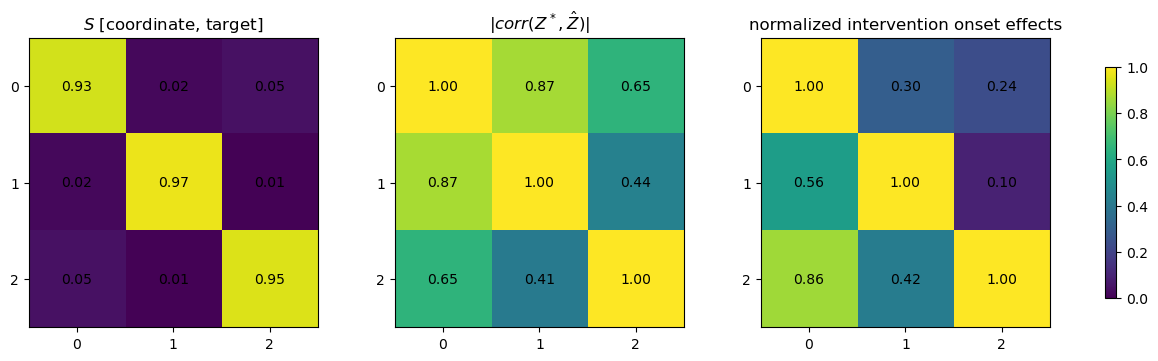

In [15]:
def abs_corr_matrix(Z_true, Z_hat):
    truth = Z_true.reshape(-1, A)
    estimate = Z_hat.reshape(-1, A)
    matrix = np.zeros((A, A), dtype=np.float64)
    for a in range(A):
        for b in range(A):
            matrix[a, b] = abs(np.corrcoef(
                truth[:, a],
                estimate[:, b],
            )[0, 1])
    return matrix


def intervention_onset_effect(Z):
    delta = Z[:, 1, :] - Z[:, 0, :]
    effect = np.zeros((A, A), dtype=np.float64)
    for target in range(A):
        active = I_np[:, target] > 0.5
        inactive = ~active
        effect[target] = np.abs(
            delta[active].mean(axis=0)
            - delta[inactive].mean(axis=0)
        )
    return effect


def sinkhorn_assignment(effect, temperature=SINKHORN_TEMP, n_iter=SINKHORN_ITERS):
    normalized = effect / (
        effect.max(axis=1, keepdims=True) + 1e-12
    )
    S = np.exp(normalized.T / temperature)
    for _ in range(n_iter):
        S /= S.sum(axis=1, keepdims=True) + 1e-12
        S /= S.sum(axis=0, keepdims=True) + 1e-12
    return S


coordinate_state = long_result['coordinate_state']
Z_final = coordinate_state['Z']
X_final = coordinate_state['X']

C_final = abs_corr_matrix(Z_true_np, Z_final)
E_final = intervention_onset_effect(Z_final)
S_final = sinkhorn_assignment(E_final)

coordinate_index, target_index = linear_sum_assignment(-S_final)
coord_for_target = np.empty(A, dtype=int)
for coordinate, target in zip(coordinate_index, target_index):
    coord_for_target[target] = coordinate

coord_r2_final = coordinate_affine_r2(Z_final)

print('dense affine R2 of X:', dense_affine_r2(X_final))
print('same-target affine R2 after psi:', np.round(coord_r2_final, 5))
print('hard target -> coordinate assignment:', tuple(coord_for_target.tolist()))
print('condition number of W:', np.linalg.cond(coordinate_state['W']))
print('W W^T:')
print(np.round(
    coordinate_state['W'] @ coordinate_state['W'].T,
    3,
))
print('intervention cross-covariance singular values:')
print(np.round(coordinate_state['crosscov_singular'], 5))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), constrained_layout=True)
for ax, matrix, title in zip(
    axes,
    [S_final, C_final, E_final / (E_final.max(axis=1, keepdims=True) + 1e-12)],
    [
        r'$S$ [coordinate, target]',
        r'$|corr(Z^*, \hat Z)|$',
        'normalized intervention onset effects',
    ],
):
    im = ax.imshow(matrix, vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xticks(range(A))
    ax.set_yticks(range(A))
    for i in range(A):
        for j in range(A):
            ax.text(j, i, f'{matrix[i, j]:.2f}', ha='center', va='center')
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.show()

## 13. Graph-particle diagnostics

,pair_index,d_lag,d_inst,count,frequency
1,1321,0,0,22,0.68750
2,1324,0,1,7,0.21875
0,521,1,0,3,0.09375


v111 point optimum distances: 0 0
particle true-graph fraction: 0.6875
particle mean distances: {'d_lag': 0.09375, 'd_inst': 0.21875}
unique particle graphs: 3


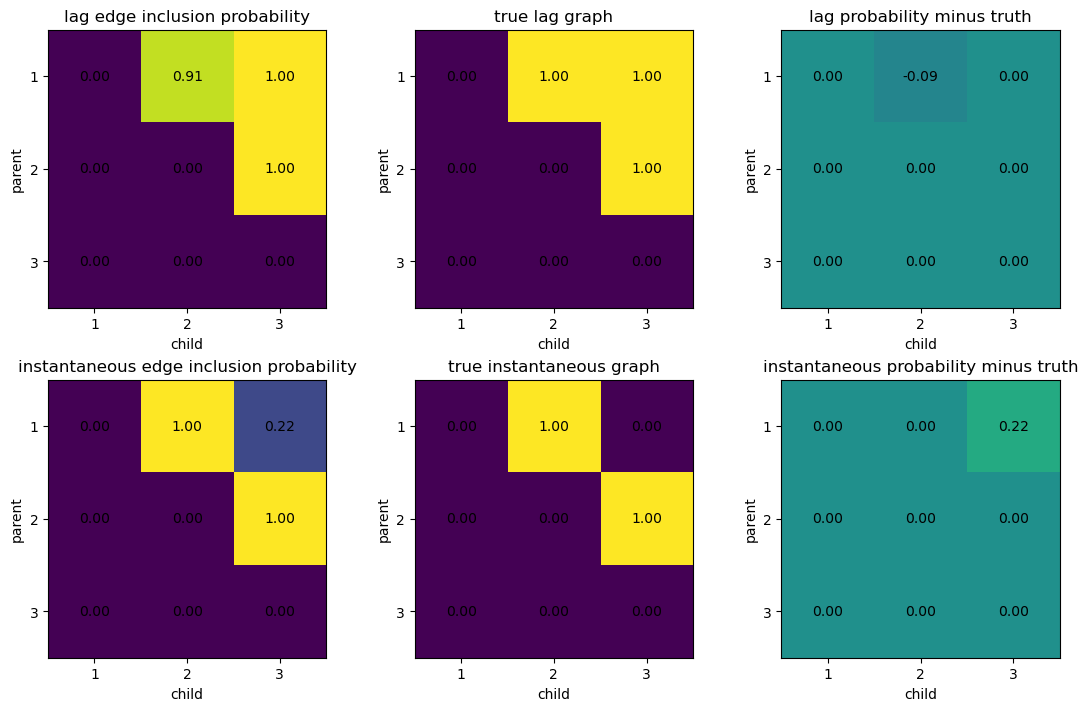

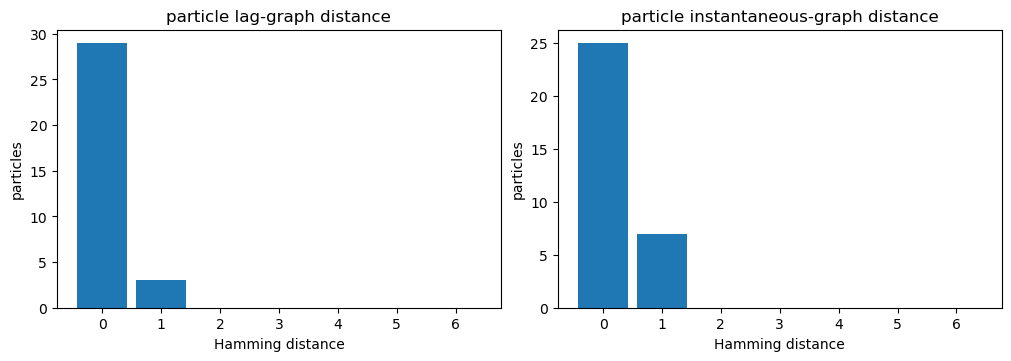

In [16]:
pair_indices = long_result['pair_indices']
graph_summary = particle_graph_summary(pair_indices)
lag_probability, inst_probability = edge_inclusion_probabilities(pair_indices)
v111_best = long_result['v111_best']

frequency = (
    graph_summary.groupby(['pair_index', 'd_lag', 'd_inst'])
    .size().rename('count').reset_index()
    .sort_values('count', ascending=False)
)
frequency['frequency'] = frequency['count'] / N_PARTICLES

display(frequency.head(12))
print('v111 point optimum distances:', v111_best['d_lag'], v111_best['d_inst'])
print('particle true-graph fraction:', float(np.mean(
    (graph_summary['d_lag'] == 0) & (graph_summary['d_inst'] == 0)
)))
print('particle mean distances:',
      graph_summary[['d_lag', 'd_inst']].mean().to_dict())
print('unique particle graphs:', graph_summary['pair_index'].nunique())

fig, axes = plt.subplots(2, 3, figsize=(11, 7), constrained_layout=True)
panels = [
    (axes[0, 0], lag_probability, 'lag edge inclusion probability', 0, 1),
    (axes[0, 1], TRUE_LAG, 'true lag graph', 0, 1),
    (axes[0, 2], lag_probability - TRUE_LAG, 'lag probability minus truth', -1, 1),
    (axes[1, 0], inst_probability, 'instantaneous edge inclusion probability', 0, 1),
    (axes[1, 1], TRUE_INST, 'true instantaneous graph', 0, 1),
    (axes[1, 2], inst_probability - TRUE_INST, 'instantaneous probability minus truth', -1, 1),
]
for ax, matrix, title, vmin, vmax in panels:
    im = ax.imshow(matrix, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel('child')
    ax.set_ylabel('parent')
    ax.set_xticks(range(A)); ax.set_yticks(range(A))
    ax.set_xticklabels([1, 2, 3]); ax.set_yticklabels([1, 2, 3])
    for i in range(A):
        for j in range(A):
            ax.text(j, i, f'{matrix[i, j]:.2f}', ha='center', va='center')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
axes[0].hist(graph_summary['d_lag'], bins=np.arange(-0.5, 7.5, 1), rwidth=0.85)
axes[0].set_title('particle lag-graph distance')
axes[0].set_xlabel('Hamming distance'); axes[0].set_ylabel('particles')
axes[1].hist(graph_summary['d_inst'], bins=np.arange(-0.5, 7.5, 1), rwidth=0.85)
axes[1].set_title('particle instantaneous-graph distance')
axes[1].set_xlabel('Hamming distance'); axes[1].set_ylabel('particles')
plt.show()

## 14. Mechanism-particle diagnostics

,child,ensemble validation R2,mean particle validation R2,minimum particle validation R2,prediction spread SD
0,1,0.370111,0.370043,0.369233,0.007457
1,2,0.968281,0.968118,0.966685,0.027468
2,3,0.830851,0.830585,0.829789,0.019279


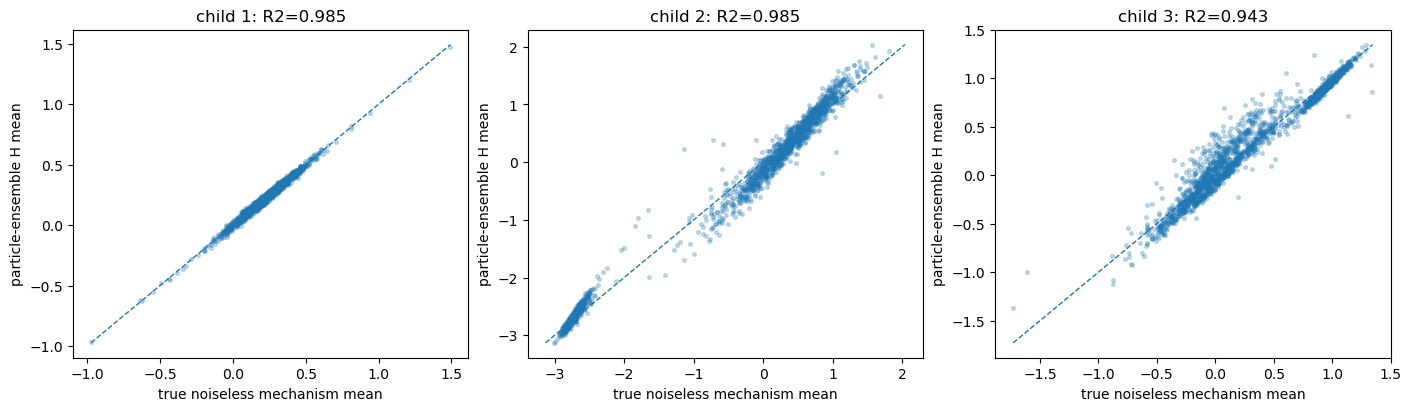

,child,ensemble true-mechanism R2,ensemble true-mechanism RMSE,mean 90% band width,90% band coverage of true mean
0,1,0.985048,0.018141,0.006085,0.130435
1,2,0.984712,0.178744,0.052797,0.121843
2,3,0.942688,0.120053,0.021854,0.085399


,particle,child,pair_index,d_total,beta_0,beta_1,beta_2,beta_3,beta_4,beta_5,beta_6,beta_7
0,0,1,1321,0,-0.05755,0.55983,0.00000,0.00000,0.0,0.00000,0.00000,0.0
1,0,2,1321,0,-0.12381,0.80068,-0.30965,0.00000,0.0,-0.59494,0.00000,-0.0
2,0,3,1321,0,0.21543,0.62810,0.60200,1.07255,0.0,0.00000,-1.12765,0.0
3,1,1,521,1,-0.04704,0.55704,0.00000,0.00000,0.0,0.00000,0.00000,0.0
4,1,2,521,1,-0.09787,0.84072,0.00000,0.00000,0.0,-0.71608,0.00000,0.0


In [17]:
Z_final = long_result['coordinate_state']['Z']
H_table, particle_predictions, H_targets = particle_prediction_diagnostics(
    Z_final,
    pair_indices,
    long_result['H_particles'],
)
display(H_table.round(6))

# Coordinatewise affine maps to the true latent scale, fitted on training trajectories.
alignment_slope = np.zeros(A)
alignment_intercept = np.zeros(A)
for a in range(A):
    x = Z_final[train_idx, :, a].reshape(-1)
    y = Z_true_np[train_idx, :, a].reshape(-1)
    design = np.stack([x, np.ones_like(x)], axis=1)
    coefficient = np.linalg.lstsq(design, y, rcond=None)[0]
    alignment_slope[a] = coefficient[0]
    alignment_intercept[a] = coefficient[1]


def true_observational_mean(child, split):
    z_prev = Z_true_np[split, :-1].reshape(-1, A)
    z_curr = Z_true_np[split, 1:].reshape(-1, A)
    interventions = np.repeat(I_np[split], L - 1, axis=0)
    observed = interventions[:, child] < 0.5
    z_prev = z_prev[observed]
    z_curr = z_curr[observed]

    mu = true_bias[child] + true_self[child] * z_prev[:, child]
    for parent in range(A):
        if TRUE_LAG[parent, child] > 0.5:
            mu = mu + true_lag_coef[parent, child] * np.tanh(z_prev[:, parent])
        if TRUE_INST[parent, child] > 0.5:
            mu = mu + true_inst_coef[parent, child] * np.tanh(z_curr[:, parent])
    return mu


mechanism_rows = []
fig, axes = plt.subplots(1, A, figsize=(14, 4), constrained_layout=True)
plot_rng = np.random.default_rng(SEED + 99)

for child, ax in enumerate(axes):
    prediction_true_scale = (
        alignment_slope[child] * particle_predictions[child]
        + alignment_intercept[child]
    )
    ensemble_mean = prediction_true_scale.mean(axis=0)
    lower = np.quantile(prediction_true_scale, 0.05, axis=0)
    upper = np.quantile(prediction_true_scale, 0.95, axis=0)
    true_mean = true_observational_mean(child, val_idx)

    mechanism_rows.append({
        'child': child + 1,
        'ensemble true-mechanism R2': float(r2_score(true_mean, ensemble_mean)),
        'ensemble true-mechanism RMSE': float(np.sqrt(np.mean((true_mean - ensemble_mean) ** 2))),
        'mean 90% band width': float(np.mean(upper - lower)),
        '90% band coverage of true mean': float(np.mean((true_mean >= lower) & (true_mean <= upper))),
    })

    take = plot_rng.choice(len(true_mean), size=min(1800, len(true_mean)), replace=False)
    ax.scatter(true_mean[take], ensemble_mean[take], s=7, alpha=0.25)
    low = min(true_mean[take].min(), ensemble_mean[take].min())
    high = max(true_mean[take].max(), ensemble_mean[take].max())
    ax.plot([low, high], [low, high], linestyle='--', linewidth=1)
    ax.set_title(
        f"child {child + 1}: R2={r2_score(true_mean, ensemble_mean):.3f}"
    )
    ax.set_xlabel('true noiseless mechanism mean')
    ax.set_ylabel('particle-ensemble H mean')

plt.show()
mechanism_table = pd.DataFrame(mechanism_rows)
display(mechanism_table.round(6))

# Coefficient cloud in canonical coordinates.
coefficient_rows = []
for particle_index, pair_index in enumerate(pair_indices):
    G_lag, G_inst = GRAPH_PAIRS[int(pair_index)]
    for child in range(A):
        H = long_result['H_particles'][particle_index][child]
        coefficient_rows.append({
            'particle': particle_index,
            'child': child + 1,
            'pair_index': int(pair_index),
            'd_total': graph_distance(G_lag, G_inst)[0],
            **{f'beta_{j}': H['beta_full'][j]
               for j in range(CANONICAL_BETA_DIM)},
        })
coefficient_frame = pd.DataFrame(coefficient_rows)
display(coefficient_frame.head().round(5))

## 15. Oracle and score-landscape checks

oracle v111 distances: 0 0
learned-Z v111 distances: 0 0


,score,d_total,d_lag,d_inst
0,-0.987483,0,0,0
1,-0.988958,1,1,0
2,-0.989022,1,0,1
3,-0.990497,2,1,1
4,-0.992238,1,1,0
5,-0.992387,1,1,0
6,-0.993111,1,1,0
7,-0.993712,2,2,0
8,-0.993777,2,1,1
9,-0.993862,2,2,0


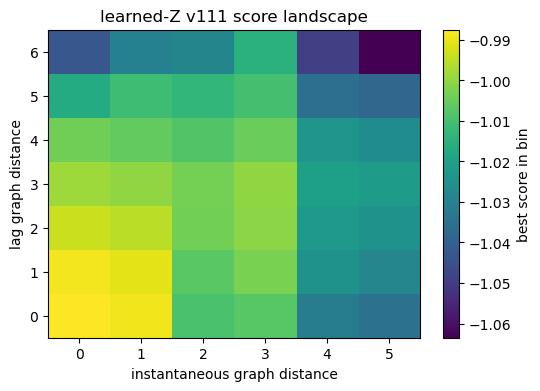

In [18]:
Z_true_standardized, _, _ = baseline_standardization(Z_true_np.astype(np.float64))
oracle_cache = fit_local_score_cache(Z_true_standardized)
oracle_scores, oracle_ll, oracle_penalty = score_graph_pairs(oracle_cache)
oracle_best = v111_best_graph(oracle_scores)

print('oracle v111 distances:', oracle_best['d_lag'], oracle_best['d_inst'])
print('learned-Z v111 distances:', v111_best['d_lag'], v111_best['d_inst'])

rows = []
for pair_index, score in enumerate(long_result['scores']):
    G_lag, G_inst = GRAPH_PAIRS[pair_index]
    d_total, d_lag, d_inst = graph_distance(G_lag, G_inst)
    rows.append({'score': score, 'd_total': d_total, 'd_lag': d_lag, 'd_inst': d_inst})
score_df = pd.DataFrame(rows).sort_values('score', ascending=False).reset_index(drop=True)
display(score_df.head(10).round(6))

landscape = score_df.pivot_table(
    index='d_lag', columns='d_inst', values='score', aggfunc='max'
)
plt.figure(figsize=(6, 4))
plt.imshow(landscape.to_numpy(), aspect='auto', origin='lower')
plt.title('learned-Z v111 score landscape')
plt.xlabel('instantaneous graph distance')
plt.ylabel('lag graph distance')
plt.xticks(range(len(landscape.columns)), landscape.columns.astype(int))
plt.yticks(range(len(landscape.index)), landscape.index.astype(int))
plt.colorbar(label='best score in bin')
plt.show()

## 16. Final pass/fail summary

In [19]:
final_coordinate_r2 = coordinate_affine_r2(Z_final)
true_fraction = float(np.mean(
    (graph_summary['d_lag'] == 0) & (graph_summary['d_inst'] == 0)
))
mean_total_distance = float(graph_summary['d_total'].mean())
unique_graphs = int(graph_summary['pair_index'].nunique())
mean_mechanism_r2 = float(mechanism_table['ensemble true-mechanism R2'].mean())
mean_band_width = float(mechanism_table['mean 90% band width'].mean())

summary = pd.DataFrame({
    'check': [
        'iteration-count prefix invariance',
        'convergence reached',
        'mean coordinate affine R2',
        'oracle v111 lag graph distance',
        'oracle v111 instantaneous graph distance',
        'learned-Z v111 lag graph distance',
        'learned-Z v111 instantaneous graph distance',
        'particle true-graph fraction',
        'particle mean total graph distance',
        'more than one unique graph particle',
        'mean ensemble true-mechanism R2',
        'nonzero mechanism-particle spread',
    ],
    'value': [
        prefix_equal,
        long_result['converged'],
        float(final_coordinate_r2.mean()),
        oracle_best['d_lag'],
        oracle_best['d_inst'],
        v111_best['d_lag'],
        v111_best['d_inst'],
        true_fraction,
        mean_total_distance,
        unique_graphs,
        mean_mechanism_r2,
        mean_band_width,
    ],
    'pass': [
        prefix_equal,
        long_result['converged'],
        float(final_coordinate_r2.mean()) > 0.995,
        oracle_best['d_lag'] == 0,
        oracle_best['d_inst'] == 0,
        v111_best['d_lag'] == 0,
        v111_best['d_inst'] == 0,
        true_fraction >= 0.50,
        mean_total_distance <= 1.0,
        unique_graphs > 1,
        mean_mechanism_r2 > 0.90,
        mean_band_width > 0.0,
    ],
})
display(summary)

if bool(summary['pass'].all()):
    print(
        'PASS: the one-stage particle system remains centered on the correct '
        'graphs and mechanisms while retaining controlled exploration.'
    )
else:
    print('FAIL: inspect the failed diagnostic before expanding the model.')

print('stopping iteration:', long_result['stop_iteration'])
print('true graph fraction:', true_fraction)
print('unique graph particles:', unique_graphs)
print('mean graph distance:', mean_total_distance)

,check,value,pass
0,iteration-count prefix invariance,True,True
1,convergence reached,True,True
2,mean coordinate affine R2,0.999001,True
3,oracle v111 lag graph distance,0,True
4,oracle v111 instantaneous graph distance,0,True
5,learned-Z v111 lag graph distance,0,True
6,learned-Z v111 instantaneous graph distance,0,True
7,particle true-graph fraction,0.6875,True
8,particle mean total graph distance,0.3125,True
9,more than one unique graph particle,3,True


PASS: the one-stage particle system remains centered on the correct graphs and mechanisms while retaining controlled exploration.
stopping iteration: 27
true graph fraction: 0.6875
unique graph particles: 3
mean graph distance: 0.3125
